In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pregunta 1
Lee en un dataframe el fichero `examen.csv` que se entrega junto con el enunciado .

In [69]:
df_examen = pd.read_csv('examen.csv', sep=';')

# Pregunta 2
Observe que la columna que expresa la altura contiene un numero decimal, pero con los decimales separados por comas. Esto implica que Python lo interpreta como una cadena de caracteres y no como un numero.  
Se desea cambiar el formato a la columna `Altura_cad` para que sea de tipo número decimal (es decir que los decimales vayan separados por un punto). Cree una nueva columna `Altura` que almacene este numero.

**NOTA**: la función `float(cadena)` recibe una cadena como parámetro y devuelve un numero decimal

In [70]:
#Vamos a seguir los siguientes pasos para tener un código más fácil de leer

#primero creamos una variable para almacenar la columna Altura_cad del data frame con selección directa
columna_original = df_examen['Altura_cad']

#vamos a crear una variable llamada valores_transformados para aplicarle dos funciones/métodos para strings, ya que por cómo está escrito lo
#reconoce como string, vamos a usar replace para cambiar la escritura y usaremos astype para convertir el tipo de dato de str a float, función de Pandas
valores_transformados = columna_original.str.replace(',', '.').astype(float)

#por último vamos a usar el acceso directo y escribir que valores queremos que tome nuestra función, que como codeamos es la columna orginal mofificada
df_examen['Altura'] = valores_transformados

# Pregunta 3
Elimine la columna `Altura_cad` del dataframe

In [71]:
# haré dos pasos extras para evitar errores, voy a hacer una verificación previa y usaré .column como índice en pandas para que de información de las columnas y usaré el método .tolist() para 
#formatear el array en una lista standard de python
print("Columnas disponibles:", df_examen.columns.tolist())


#Ahora usaré lo aprendido en manipulación de data frames I, usaremos drop() aclarando el axis=1 para eliminar la columna, con inplace=True para 
#elimarlo del data frame original

df_examen.drop('Altura_cad', axis=1, inplace=True)

#como segundo paso extra, yo imprimiré con print el data frame df_examen con head(1) para mostrar solamente la primera 1-columna

print(df_examen.head(1))



Columnas disponibles: ['id', 'Nombre', 'Peso', 'Altura_cad', 'Gimnasio', 'Altura']
   id       Nombre  Peso Gimnasio  Altura
0   1  Carlos Ruiz   NaN       Si    1.49


# Pregunta 4
Rellene los nulos de la columna `Peso` con el valor medio de la columa `Peso`.

In [72]:
#ahora usaré lo que se vió en el módulo F. de limpieza de datos usaremos más específicamente las funciones mostradas en el pdf de limpieza de datos 
#ausentes más específicamente la técnica de imputación por mean

# primero debemos calcular la media de la columna Peso  y la almacenaremos en media_peso, usaremos selección directa de la columna Peso y el método mean
media_peso = df_examen['Peso'].mean()

# Imputaré los nulos con la media, uso de nuevo selecc. dir. y el método fillna() que me permitie modificar todos los NaN
df_examen['Peso'] = df_examen['Peso'].fillna(media_peso)

# Pregunta 5
Obtenga el peso media de las personas que van al gimnasio y de las que no van

In [73]:
# calcularemos la media de peso de los que asisten al gimnasio y lo almacenaremos, usaremos el método de manipulación de datos groupby para depurar 
#y filtrar que se encuentra en la clase de manipulación de datos II, luego aplicaremos el método estadístico mean.() y finalmente ['Si'] para acceder
media_peso_gimnasio_si = df_examen.groupby('Gimnasio')['Peso'].mean()['Si']

# Pregunta 6
Cree una nueva columna que se llame `Altos_Bajos`que contenga la cadena `Alto` cuando el valor de la altura sea mayor que la media, y `Bajo`cuando el valor de la altura se menor que la media.

In [74]:
#usaremos df_examen.groupby para crear una suerte de serie booleana que asignará valor 1 a los valores que cumplan la condición a continuación
#1 equivale a True y 0 equivale a 0 cualquier cosa que no sea True (conocimiento adquirido en mi carrera)
df_examen['Altos_Bajos'] = df_examen.groupby(
    #usaremos una condición dentro del groupby para que cuando la altura sea mayor que la media use la cadena Alto y cuando es menor Bajo
    df_examen['Altura'] > df_examen['Altura'].mean()
#ngroup asignará valores enteros y map reemplazará los valores según corresponda, en este caso usaré un diccionario
).ngroup().map({0: 'Bajo', 1: 'Alto'})


#como paso extra imprimiré las columnas haciendo uso de print y el df, sé que no es requerido pero quiero verificar qué tal imprime, además imprimiré 
#la media de altura para ver su correcta funcionamiento, emplearé un formato de f-string para poder emplear dos tipos de datos
media_altura = df_examen['Altura'].mean()
print(f"(He aquí mis pasos extras) La media de la altura es: {media_altura:.2f} metros")
print(df_examen[['Altura', 'Altos_Bajos']])

(He aquí mis pasos extras) La media de la altura es: 1.74 metros
     Altura Altos_Bajos
0      1.49        Bajo
1      1.88        Alto
2      1.53        Bajo
3      1.60        Bajo
4      1.59        Bajo
..      ...         ...
145    1.61        Bajo
146    1.91        Alto
147    1.80        Alto
148    1.81        Alto
149    1.93        Alto

[150 rows x 2 columns]


# Pregunta 7
Dibuje una grafica tipo scatter cuyos ejes sean el peso (eje X) y la altura (eje Y). La grafica debe tener un titulo, y las etiquetas de los ejes, que expresaran las variables de la grafica.

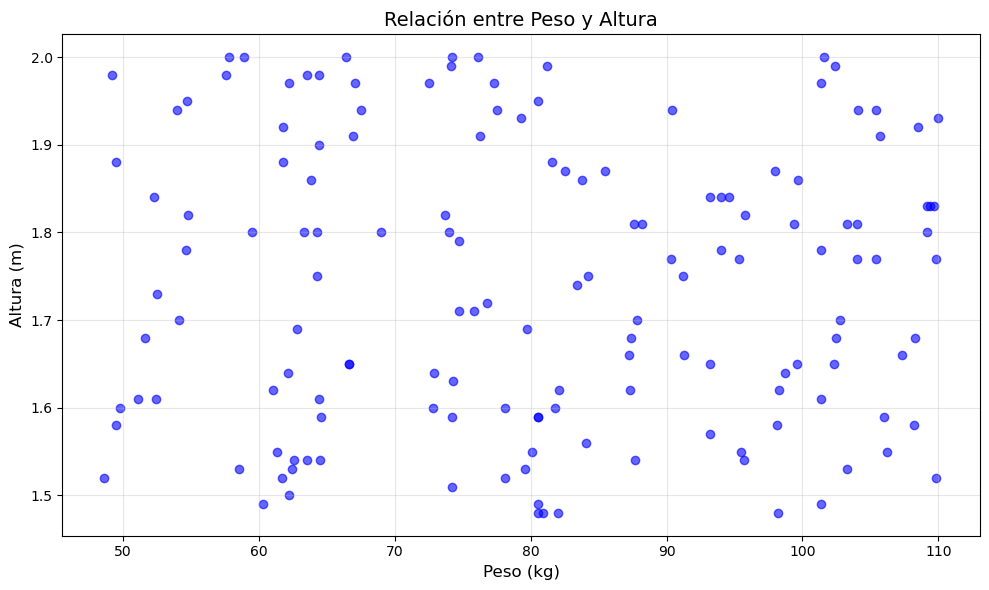

In [66]:
plt.figure(figsize=(10, 6))

#elegimos gráfica tipo scatter, con etiquetas en los ejes expresando las variables
plt.scatter(df_examen['Peso'], df_examen['Altura'], alpha=0.6, color='blue')

#elijo el título y su tamaño de fuente (fontsize)
plt.title('Relación entre Peso y Altura', fontsize=14)

#elijo el tamaño de fuente para la etiqueta y su nombre, basado en la variable que representan, del eje x y el eje y 
plt.xlabel('Peso (kg)', fontsize=12)
plt.ylabel('Altura (m)', fontsize=12)

#añado por preferencia la función de la librería matplotlib .grid para agregar una grilla/regilla
plt.grid(True, alpha=0.3)

#me aseguro que se formatee bien
plt.tight_layout()

#por último forzamos la visualización
plt.show()

# Pregunta 8
Dibuje una grafica tipo scatter cuyos ejes sean el peso (eje X) y la altura (eje Y). La grafica debe tener un titulo, y las etiquetas de los ejes, que expresaran las variables de la grafica. Muestre las personas que van al ginnasio de un color diferente a las que no van, y muestre la leyenda para saber a que tipo pertenece cada punto.

C:\Users\Compaq\AppData\Local\Temp\ipykernel_10768\1903719520.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_examen.groupby('Gimnasio').apply(


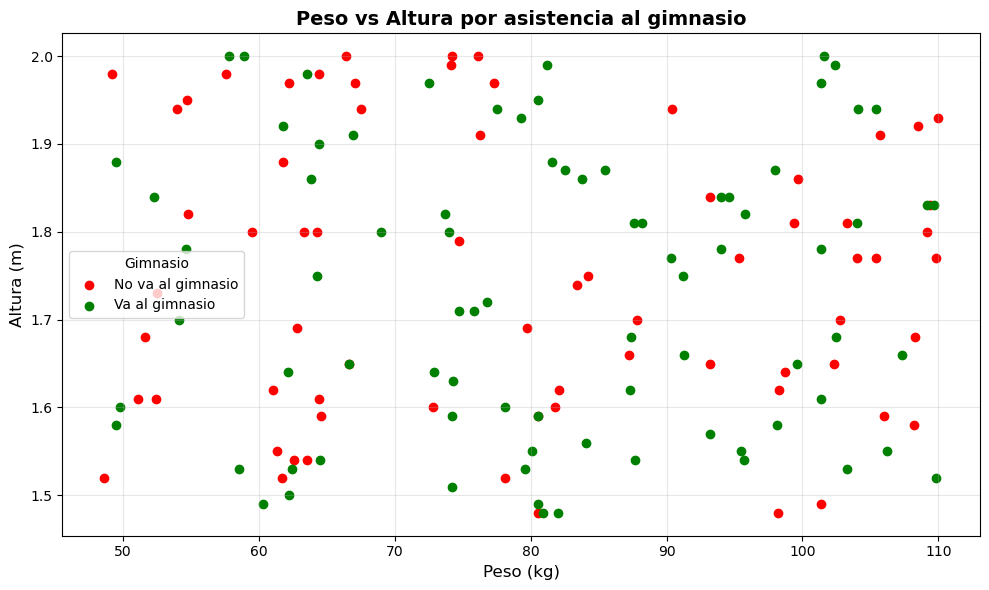

In [67]:
plt.figure(figsize=(10, 6))

# se me ocurrió que usar un diccionario de claves y valores para los colores iba a ser útil
colores = {'Si': 'green', 'No': 'red'}

#creo otro diccionario para las etiquetas
etiquetas = {'Si': 'Va al gimnasio', 'No': 'No va al gimnasio'}

# hago un .groupby para depurar y uso .apply para  aplicar mi función propia con lambda, grupo  y otras cosillas
df_examen.groupby('Gimnasio').apply(
    lambda grupo: plt.scatter(
        grupo['Peso'], 
        grupo['Altura'],
        color=colores[grupo.name],
        label=etiquetas[grupo.name],

    )
)

# Personalizo en el siguiente orden: título, etiquetas de los ejes x e y con sus respectivos tamaños de fuente bien legibles, y finalizo con los mismos
# tres pasos de la visualización anterior
plt.title('Peso vs Altura por asistencia al gimnasio', fontsize=14, fontweight='bold')
plt.xlabel('Peso (kg)', fontsize=12)
plt.ylabel('Altura (m)', fontsize=12)
plt.legend(title='Gimnasio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()